In [14]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline

Plot de función de activación ReLu y su derivada construyendo la funcion.

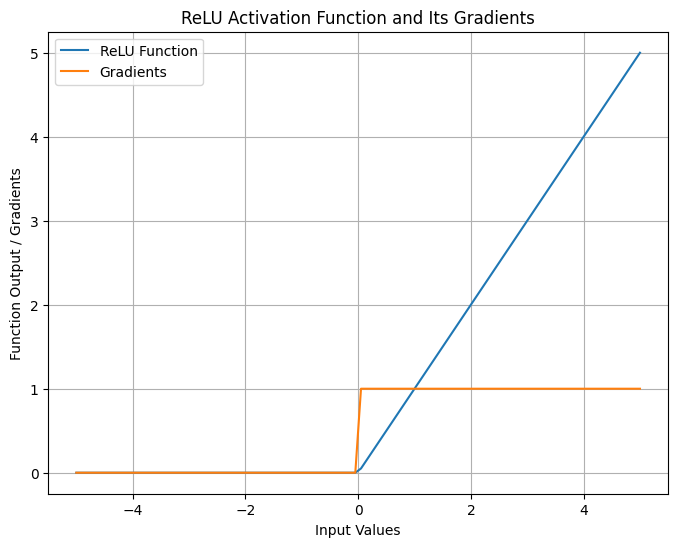

In [15]:

import torch
import matplotlib.pyplot as plt

# Define the activation function (e.g., ReLU)
def relu(x):
    return torch.max(x, torch.zeros_like(x))

# Create a range of input values
x = torch.linspace(-5, 5, 100, requires_grad=True)

# Calculate the output of the ReLU function
y = relu(x)

# Compute the gradients of y with respect to x
y.backward(torch.ones_like(x))

# Extract the gradients
gradients = x.grad

# Plot the input values, ReLU function, and their gradients
plt.figure(figsize=(8, 6))
plt.plot(x.detach().numpy(), y.detach().numpy(), label='ReLU Function')
plt.plot(x.detach().numpy(), gradients.detach().numpy(), label='Gradients')
plt.title("ReLU Activation Function and Its Gradients")
plt.xlabel("Input Values")
plt.ylabel("Function Output / Gradients")
plt.grid()
plt.legend()
plt.show()



Usando Pytorch directo

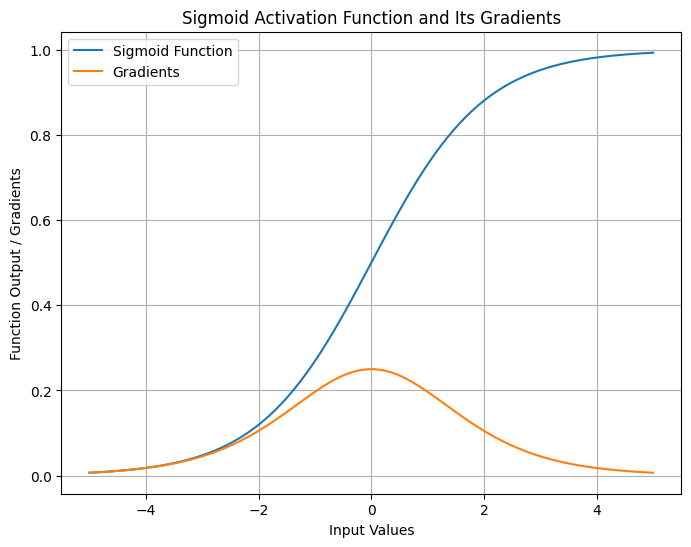

In [16]:
#-----
# Create a range of input values
x2 = torch.linspace(-5, 5, 100, requires_grad=True)
y2 = torch.sigmoid(x2)  # Use the sigmoid function

# Compute the gradients of y with respect to x2
y2.backward(torch.ones_like(x2))

# Extract the gradients
gradients2 = x2.grad

# Plot the input values, Sigmoid function, and their gradients
plt.figure(figsize=(8, 6))
plt.plot(x2.detach().numpy(), y2.detach().numpy(), label='Sigmoid Function')  # Update the label
plt.plot(x2.detach().numpy(), gradients2.detach().numpy(), label='Gradients')
plt.title("Sigmoid Activation Function and Its Gradients")
plt.xlabel("Input Values")
plt.ylabel("Function Output / Gradients")
plt.grid()
plt.legend()
plt.show()

Faltan agregar LeakyReLu, ELU, Swish (SiLU)

In [17]:
#####TODO


# MNIST clasificacion de digitos con MLP
Perceptron multilayer para clasificar MNIST


In [18]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Using PyTorch version:', torch.__version__, ' Device:', device)

Using PyTorch version: 2.1.0+cu118  Device: cuda


## Data

Bajamos y cargamos los datos. Usamos aca el set de test para validación.

In [19]:
batch_size = 32

train_dataset = datasets.MNIST('./data',
                               train=True,
                               download=True,
                               transform=transforms.ToTensor())

validation_dataset = datasets.MNIST('./data',
                                    train=False,
                                    transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset,
                                                batch_size=batch_size,
                                                shuffle=False)

Los datos de entrenamiento y prueba se proporcionan a través de cargadores de datos (train_loader) que ofrecen iteradores a través de los conjuntos de datos. El primer elemento de los datos de entrenamiento (X_train) es un tensor de cuarto orden de tamaño (batch_size, 1, 28, 28), es decir, consta de un lote de imágenes de tamaño 1x28x28 píxeles. y_train es un vector que contiene las clases correctas ("0", "1", ..., "9") para cada dígito de entrenamiento.

In [20]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
y_train: torch.Size([32]) type: torch.LongTensor




```
# This is formatted as code
```

Primeros diez digitos


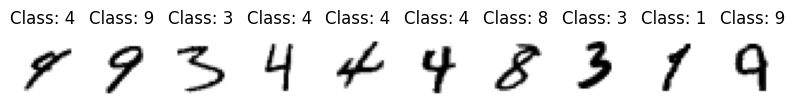

In [21]:
pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.axis('off')
    plt.imshow(X_train[i,:,:,:].numpy().reshape(28,28), cmap="gray_r")
    plt.title('Class: '+str(y_train[i].item()))

[link text](https://)## MLP network

Definamos la red como una clase en Python. Debemos escribir los métodos __init__() y forward(), y PyTorch generará automáticamente un método backward() para calcular los gradientes para el paso hacia atrás.

Finalmente, definimos un optimizador para actualizar los parámetros del modelo en función de los gradientes calculados. Seleccionamos el descenso de gradiente estocástico (con momento) como el algoritmo de optimización y establecemos la tasa de aprendizaje en 0.01. (http://pytorch.org/docs/optim.html#algorithms)

In [22]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc3 = nn.Linear(50, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Aplana la imagen
        x = relu(self.fc1(x))
        x = relu(self.fc2(x))
        return F.log_softmax(self.fc3(x), dim=1)

model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
criterion = nn.CrossEntropyLoss()

print(model)

Net(
  (fc1): Linear(in_features=784, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=10, bias=True)
)


## Learning

Let's now define functions to `train()` and `validate()` the model.

In [23]:
def train(epoch, log_interval=200):
    # Set model to training mode
    model.train()

    # Loop over each batch from the training set
    for batch_idx, (data, target) in enumerate(train_loader):
        # Copy data to GPU if needed
        data = data.to(device)
        target = target.to(device)

        # Zero gradient buffers
        optimizer.zero_grad()

        # Pass data through the network
        output = model(data)

        # Calculate loss
        loss = criterion(output, target)

        # Backpropagate
        loss.backward()

        # Update weights
        optimizer.step()

        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.data.item()))

In [24]:
def validate(loss_vector, accuracy_vector):
    model.eval()
    val_loss, correct = 0, 0
    for data, target in validation_loader:
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        val_loss += criterion(output, target).data.item()
        pred = output.data.max(1)[1] # get the index of the max log-probability
        correct += pred.eq(target.data).cpu().sum()

    val_loss /= len(validation_loader)
    loss_vector.append(val_loss)

    accuracy = 100. * correct.to(torch.float32) / len(validation_loader.dataset)
    accuracy_vector.append(accuracy)

    print('\nValidation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        val_loss, correct, len(validation_loader.dataset), accuracy))



Ahora estamos listos para entrenar nuestro modelo utilizando la función train(). Un "epoch" significa un pase a través de todos los datos de entrenamiento. Después de cada epoch, evaluamos el modelo utilizando la función validate().



In [25]:
%%time
epochs = 4

lossv, accv = [], []
for epoch in range(1, epochs + 1):
    train(epoch)
    validate(lossv, accv)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.301436
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.060393
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.202262
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.802189
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.599912
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.733736
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.339877
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.186501
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.614110
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.292270

Validation set: Average loss: 0.3336, Accuracy: 9052/10000 (91%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.106287
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.417049
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.674053
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.520917
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.460638
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.082159
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.270032
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.157924
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.35

Para visualizar cómo progresó el entrenamiento de tu modelo, puedes graficar la pérdida y la precisión (accuracy) en el conjunto de prueba a lo largo de las epochs.

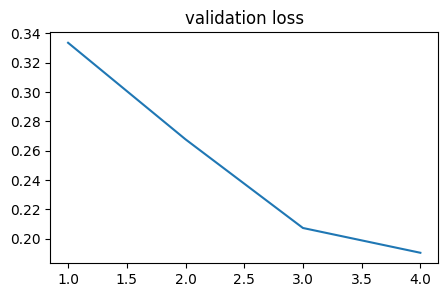

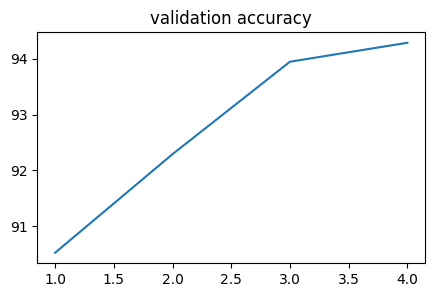

In [26]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epochs+1), lossv)
plt.title('validation loss')

plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epochs+1), accv)
plt.title('validation accuracy');